# Lecture 09 — Logistic Regression (sklearn Companion Notebook)

This notebook walks through everything from the lecture slides, but hands-on: every idea gets
its own small experiment using `scikit-learn`, `numpy`, and `matplotlib`.

**Contents**

1. Setup
2. Why not Linear Regression for classification?
3. The Sigmoid function
4. The Logistic Regression equation
5. Odds — not the same as probability
6. Log-odds (logit) — the straight line hiding inside the curve
7. Odds ratios — interpreting coefficients
8. The decision boundary is always a straight line
9. Log loss (binary cross-entropy)
10. Regularization: L1 vs L2
11. The `C` parameter
12. Multiclass Logistic Regression (softmax)
13. Limitations — when a straight line isn't enough
14. KNN vs. Decision Tree vs. Logistic Regression, side by side
15. Strengths & weaknesses, in code
16. The full workflow, once more
17. Summary


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, log_loss, classification_report
)
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


## 2. Why Not Just Use Linear Regression?

> A tempting first idea: fit a straight line to 0/1 data, treat the line's output as a probability.

Two things go wrong immediately — the predicted "probability" can go below 0 or above 1.
Let's build the exact toy example from the slide: hours studied vs. pass/fail.

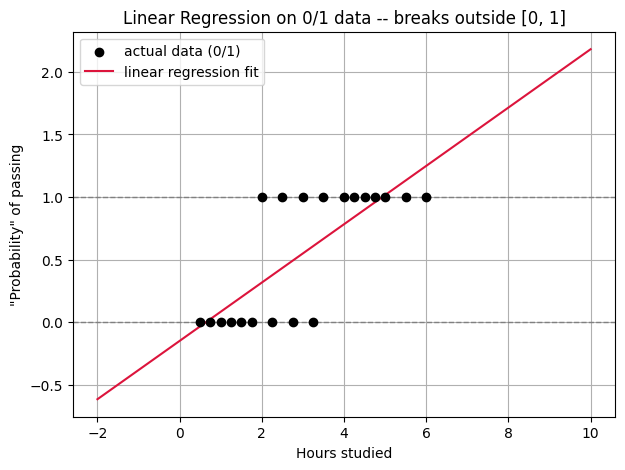

Predicted 'probability' at 0 hours studied:  -0.15
Predicted 'probability' at 9 hours studied:  1.95


In [2]:
# Toy dataset: hours studied -> passed (0/1)
hours = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75,
                   3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5, 6.0]).reshape(-1, 1)
passed = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
                    1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

lin_reg = LinearRegression().fit(hours, passed)

x_line = np.linspace(-2, 10, 200).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

plt.scatter(hours, passed, color="black", zorder=3, label="actual data (0/1)")
plt.plot(x_line, y_line, color="crimson", label="linear regression fit")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axhline(1, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Hours studied")
plt.ylabel('"Probability" of passing')
plt.title("Linear Regression on 0/1 data -- breaks outside [0, 1]")
plt.legend()
plt.show()

print(f"Predicted 'probability' at 0 hours studied:  {lin_reg.predict([[0]])[0]:.2f}")
print(f"Predicted 'probability' at 9 hours studied:  {lin_reg.predict([[9]])[0]:.2f}")


Just like the lecture said: the line predicts nonsense like "-15% chance of passing" or
"140% chance of passing." Neither is a valid probability. We need a curve that squashes any
input into `[0, 1]` — that's the **sigmoid function**.

## 3. The Sigmoid Function

$$\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

Every real number in, a value strictly between 0 and 1 out. `z = 0` always maps to exactly 0.5.

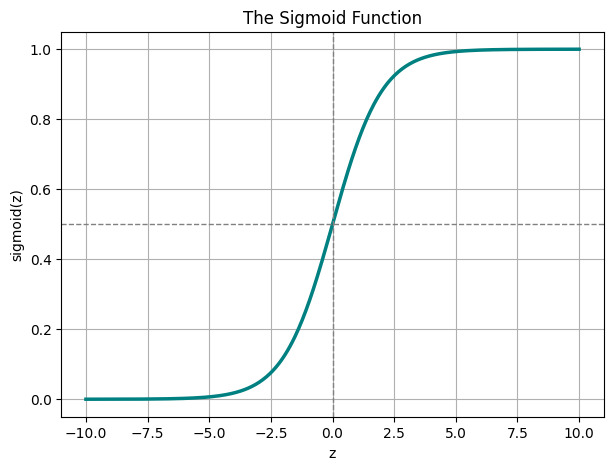

sigmoid(-10) = 0.0000
sigmoid( -2) = 0.1192
sigmoid(  0) = 0.5000
sigmoid(  2) = 0.8808
sigmoid( 10) = 1.0000


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 400)
plt.plot(z, sigmoid(z), color="teal", linewidth=2.5)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("The Sigmoid Function")
plt.show()

for test_z in [-10, -2, 0, 2, 10]:
    print(f"sigmoid({test_z:>3}) = {sigmoid(test_z):.4f}")


**No calculus needed to use this well:** large positive `z` squashes toward 1, large negative
`z` squashes toward 0, and `z = 0` always lands exactly on 0.5 — the genuine "coin flip" point.

## 4. The Logistic Regression Equation

$$P(y=1) = \text{sigmoid}(w \cdot x + b)$$

- **Step 1 — the linear part:** `z = w·x + b`, exactly Linear Regression's equation.
- **Step 2 — the squashing part:** `sigmoid(z)` turns that number into a genuine probability.
  Above 0.5 → predict class 1; below 0.5 → predict class 0.

Let's fit an actual `LogisticRegression` on the same hours-studied data.

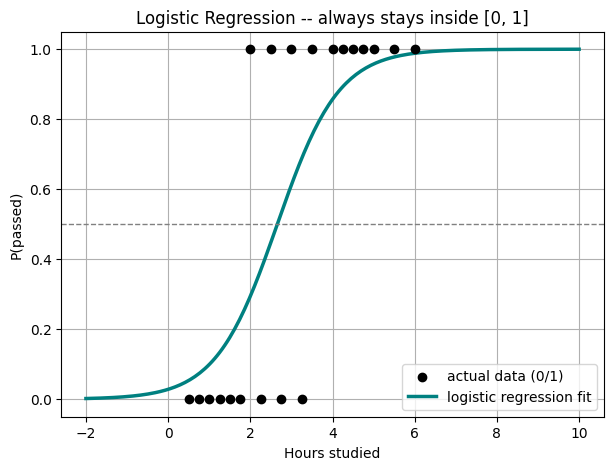

Fitted equation:  z = 1.332 * hours + -3.538
P(pass | 0 hours)  = 0.028
P(pass | 9 hours)  = 1.000


In [4]:
log_reg = LogisticRegression()
log_reg.fit(hours, passed)

x_line = np.linspace(-2, 10, 200).reshape(-1, 1)
proba_line = log_reg.predict_proba(x_line)[:, 1]

plt.scatter(hours, passed, color="black", zorder=3, label="actual data (0/1)")
plt.plot(x_line, proba_line, color="teal", linewidth=2.5, label="logistic regression fit")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Hours studied")
plt.ylabel("P(passed)")
plt.title("Logistic Regression -- always stays inside [0, 1]")
plt.legend()
plt.show()

w = log_reg.coef_[0][0]
b = log_reg.intercept_[0]
print(f"Fitted equation:  z = {w:.3f} * hours + {b:.3f}")
print(f"P(pass | 0 hours)  = {log_reg.predict_proba([[0]])[0][1]:.3f}")
print(f"P(pass | 9 hours)  = {log_reg.predict_proba([[9]])[0][1]:.3f}")


Both stay safely inside `[0, 1]` now, no matter how extreme the input. `model.predict()` just
thresholds `predict_proba()` at 0.5 — Lecture 06's threshold, unchanged.

In [5]:
print("predict_proba (class 0, class 1):")
print(log_reg.predict_proba(hours)[:6])
print()
print("predict (thresholded at 0.5):")
print(log_reg.predict(hours))


predict_proba (class 0, class 1):
[[0.94644099 0.05355901]
 [0.92682766 0.07317234]
 [0.90078484 0.09921516]
 [0.86680514 0.13319486]
 [0.82346858 0.17653142]
 [0.76977691 0.23022309]]

predict (thresholded at 0.5):
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1]


## 5. Odds: Not the Same as Probability

$$\text{odds} = \frac{p}{1-p}$$

If a customer has a 75% probability of churning, the odds of churning are `0.75 / 0.25 = 3` —
"3 to 1." Probability lives between 0 and 1; odds live between 0 and infinity.

In [6]:
def to_odds(p):
    return p / (1 - p)

probs = log_reg.predict_proba(hours)[:, 1]
odds = to_odds(probs)

demo = pd.DataFrame({
    "hours": hours.flatten(),
    "P(pass)": probs.round(3),
    "odds": odds.round(3)
})
demo.head(8)


,hours,P(pass),odds
0,0.50,0.054,0.057
1,0.75,0.073,0.079
2,1.00,0.099,0.110
3,1.25,0.133,0.154
4,1.50,0.177,0.214
5,1.75,0.230,0.299
6,2.00,0.294,0.417
7,2.25,0.368,0.582


## 6. Log-Odds (Logit): the Straight Line Hiding Inside the Curve

$$\log\left(\frac{p}{1-p}\right) = w \cdot x + b$$

Take the logarithm of the odds, and the S-shaped probability curve becomes a perfectly straight
line again. This is the whole reason for the name **"logistic regression"** — it's literally a
linear regression on the log-odds.

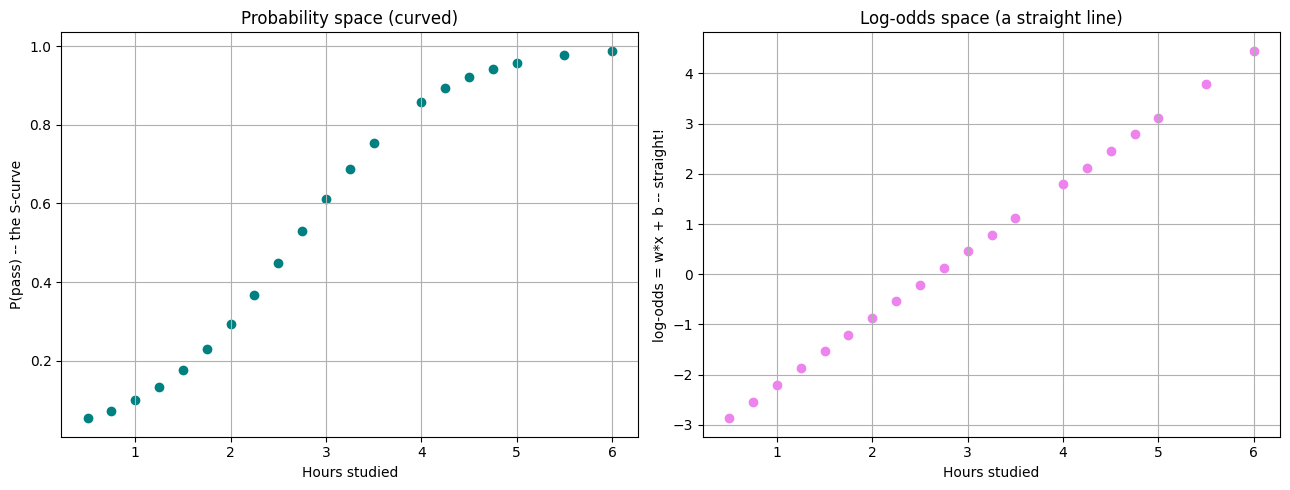

Max difference between manual w*x+b and computed log-odds: 1.1546319456101628e-14


In [7]:
log_odds = np.log(odds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(hours, probs, color="teal")
axes[0].set_xlabel("Hours studied")
axes[0].set_ylabel("P(pass) -- the S-curve")
axes[0].set_title("Probability space (curved)")

axes[1].scatter(hours, log_odds, color="violet")
axes[1].set_xlabel("Hours studied")
axes[1].set_ylabel("log-odds = w*x + b -- straight!")
axes[1].set_title("Log-odds space (a straight line)")

plt.tight_layout()
plt.show()

# Confirm it really is a straight line: log_odds should equal w*x + b exactly
predicted_log_odds = w * hours.flatten() + b
print("Max difference between manual w*x+b and computed log-odds:",
      np.max(np.abs(predicted_log_odds - log_odds)))


## 7. Interpreting Coefficients via Odds Ratios

Because the model is linear in log-odds, a coefficient `w` means "+1 unit of this feature adds
`w` to the log-odds." Exponentiating it gives something far more intuitive:

$$e^{w} = \text{odds ratio} = \text{how much the odds get } \textbf{multiplied} \text{ by, per +1 unit of the feature}$$

- Odds ratio **above 1** → the feature increases the odds
- Odds ratio **below 1** → the feature decreases the odds
- Odds ratio **exactly 1** → no effect at all

Let's build a slightly richer example (a small churn-style dataset) so we have more than one
coefficient to interpret.

In [8]:
X_churn, y_churn = make_classification(
    n_samples=400, n_features=3, n_informative=3, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.4, random_state=42
)
feature_names = ["monthly_charges", "support_tickets", "tenure_months"]
churn_df = pd.DataFrame(X_churn, columns=feature_names)
churn_df["churned"] = y_churn

model = LogisticRegression().fit(X_churn, y_churn)

odds_ratios = np.exp(model.coef_[0])
coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient (w)": model.coef_[0].round(3),
    "odds ratio (e^w)": odds_ratios.round(3)
})
coef_table


,feature,coefficient (w),odds ratio (e^w)
0,monthly_charges,2.105,8.206
1,support_tickets,-2.075,0.126
2,tenure_months,-2.878,0.056


Read a row like: *"+1 unit of `monthly_charges` multiplies the odds of churning by
`e^w`."* This is exactly what `np.exp(model.coef_)` computes — no calculus required to use it.

## 8. The Decision Boundary Is Always a Straight Line

The boundary between "predict class 0" and "predict class 1" is exactly where `sigmoid(z) = 0.5`,
which happens exactly where `z = w·x + b = 0`. In 2D that's a straight line; in higher dimensions,
a flat plane — **never a curve, never a rectangle.**

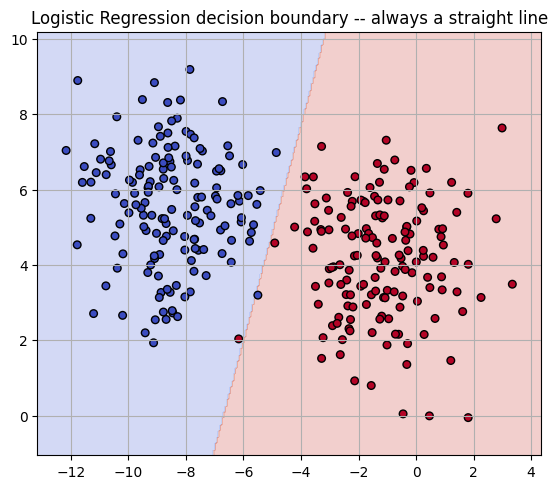

In [9]:
def plot_decision_boundary(model, X, y, ax=None, title=""):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
    ax.set_title(title)
    return ax

X_2d, y_2d = make_blobs(n_samples=300, centers=2, cluster_std=1.6, random_state=7)
boundary_model = LogisticRegression().fit(X_2d, y_2d)

plot_decision_boundary(boundary_model, X_2d, y_2d,
                        title="Logistic Regression decision boundary -- always a straight line")
plt.show()


## 9. Log Loss (Binary Cross-Entropy)

Cost for one prediction: `-log(p)` if the true label is 1, `-log(1-p)` if the true label is 0.

A confident, correct prediction costs almost nothing. A confident, **wrong** prediction shoots
toward infinity — the model is punished far more severely for being confidently wrong than for
being cautiously wrong.

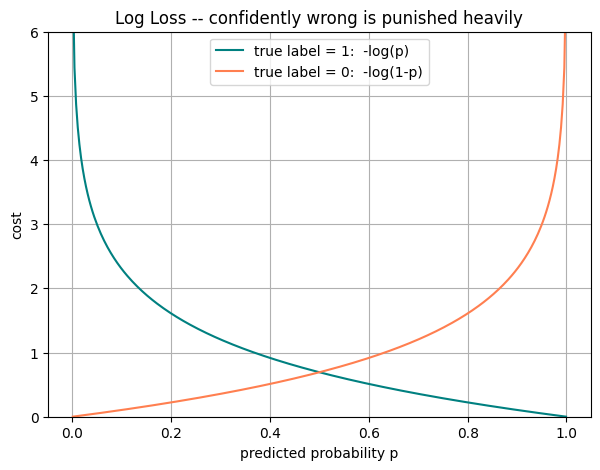

In [10]:
p = np.linspace(0.001, 0.999, 300)
cost_if_1 = -np.log(p)
cost_if_0 = -np.log(1 - p)

plt.plot(p, cost_if_1, color="teal", label="true label = 1:  -log(p)")
plt.plot(p, cost_if_0, color="coral", label="true label = 0:  -log(1-p)")
plt.xlabel("predicted probability p")
plt.ylabel("cost")
plt.title("Log Loss -- confidently wrong is punished heavily")
plt.legend()
plt.ylim(0, 6)
plt.show()


In [11]:
# Confirm sklearn's log_loss matches a manual computation
y_true = y_churn
p_hat = model.predict_proba(X_churn)[:, 1]

manual_log_loss = -np.mean(y_true * np.log(p_hat) + (1 - y_true) * np.log(1 - p_hat))
sklearn_log_loss = log_loss(y_true, p_hat)

print(f"Manual log loss:  {manual_log_loss:.5f}")
print(f"sklearn log_loss: {sklearn_log_loss:.5f}")


Manual log loss:  0.21680
sklearn log_loss: 0.21680


## 10. Regularization: L1 vs L2

Ridge (L2) and Lasso (L1) apply here in exactly the same spirit as Linear Regression — adding a
penalty for large coefficients to the cost function being minimized.

- **L2** shrinks every coefficient toward zero, smoothly.
- **L1** shrinks some coefficients all the way to **exactly zero** — feature selection as a side
  effect of fitting.

In [12]:
# A dataset with more features so shrinkage is visible
X_reg, y_reg = make_classification(
    n_samples=500, n_features=10, n_informative=4, n_redundant=2,
    class_sep=1.2, random_state=0
)
X_reg = StandardScaler().fit_transform(X_reg)  # scaling matters for regularized models

none_model = LogisticRegression(penalty=None, max_iter=5000).fit(X_reg, y_reg)
l2_model = LogisticRegression(penalty="l2", C=0.1, max_iter=5000).fit(X_reg, y_reg)
l1_model = LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=5000).fit(X_reg, y_reg)

coef_compare = pd.DataFrame({
    "no penalty": none_model.coef_[0].round(3),
    "L2 (ridge)": l2_model.coef_[0].round(3),
    "L1 (lasso)": l1_model.coef_[0].round(3),
}, index=[f"feat_{i}" for i in range(X_reg.shape[1])])
coef_compare


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

,no penalty,L2 (ridge),L1 (lasso)
feat_0,0.764,0.635,0.682
feat_1,-0.267,-0.230,0.000
feat_2,0.008,0.011,0.000
feat_3,-0.166,-0.117,0.000
feat_4,0.906,0.622,0.666
feat_5,0.096,0.072,0.000
feat_6,0.030,0.034,0.000
feat_7,1.531,1.089,1.021
feat_8,0.880,0.630,0.465
feat_9,-0.024,-0.015,0.000


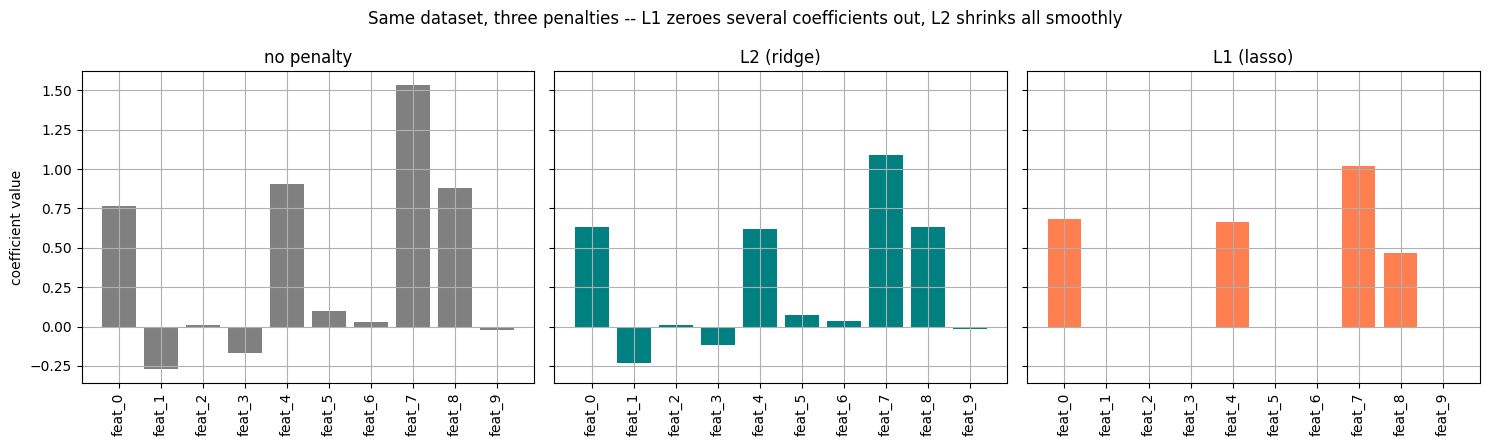

Coefficients exactly zero under L1: 6 out of 10


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, col, color in zip(axes, coef_compare.columns, ["gray", "teal", "coral"]):
    ax.bar(coef_compare.index, coef_compare[col], color=color)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=90)
axes[0].set_ylabel("coefficient value")
plt.suptitle("Same dataset, three penalties -- L1 zeroes several coefficients out, L2 shrinks all smoothly")
plt.tight_layout()
plt.show()

print("Coefficients exactly zero under L1:", np.sum(l1_model.coef_[0] == 0), "out of", X_reg.shape[1])


## 11. The `C` Parameter: Inverse Regularization Strength

`sklearn`'s `LogisticRegression` doesn't use `alpha` like Ridge/Lasso — it uses `C`, and **`C`
works backwards** from what you might expect:

- **Small `C`** = strong regularization (heavily penalize large coefficients)
- **Large `C`** = weak regularization (barely penalize them at all)

This is the opposite direction from `alpha` — worth double-checking every time. Like every other
regularization strength in this course, `C` is a hyperparameter: tune it with `GridSearchCV`, not
by guessing.

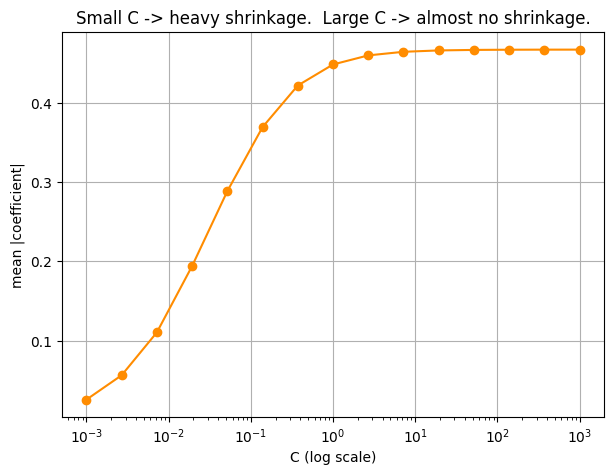

In [14]:
C_values = np.logspace(-3, 3, 15)
avg_abs_coef = []

for c in C_values:
    m = LogisticRegression(C=c, max_iter=5000).fit(X_reg, y_reg)
    avg_abs_coef.append(np.mean(np.abs(m.coef_[0])))

plt.plot(C_values, avg_abs_coef, marker="o", color="amber" if False else "darkorange")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("mean |coefficient|")
plt.title("Small C -> heavy shrinkage.  Large C -> almost no shrinkage.")
plt.show()


In [15]:
# Tune C properly with GridSearchCV, the way the lecture recommends
param_grid = {"C": np.logspace(-3, 3, 13)}
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5, scoring="f1")
grid.fit(X_reg, y_reg)

print("Best C found by cross-validation:", grid.best_params_["C"])
print("Best cross-validated F1:", round(grid.best_score_, 4))


Best C found by cross-validation: 0.31622776601683794
Best cross-validated F1: 0.7514


## 12. Multiclass Logistic Regression: Softmax

Beyond One-vs-Rest, Logistic Regression has a second, more native option: **softmax
(multinomial) regression** — one equation that directly outputs a full probability distribution
across all classes at once, guaranteed to sum to exactly 1.

> Older sklearn versions needed `multi_class='multinomial'` to request this explicitly. In
> current sklearn, softmax is the automatic default whenever `LogisticRegression` sees more than
> two classes with a solver that supports it -- no extra argument required.

Predicted class probabilities for one point: [0. 0. 1.]
They sum to: 1.0


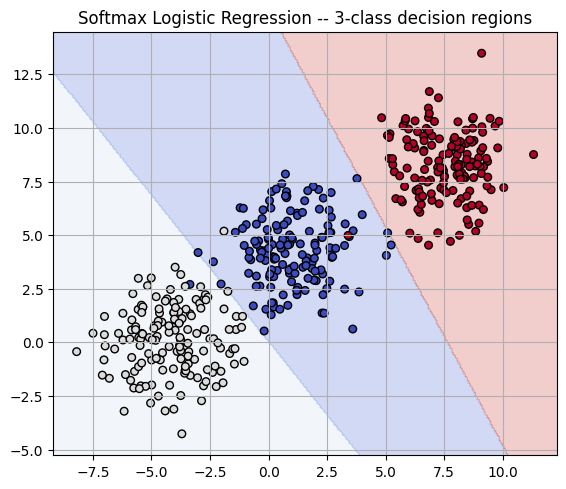

In [16]:
X_multi, y_multi = make_blobs(n_samples=450, centers=3, cluster_std=1.5, random_state=3)

# Softmax (multinomial) is fit automatically for a 3-class problem -- one joint model,
# not several one-vs-rest models stitched together.
softmax_model = LogisticRegression(max_iter=5000)
softmax_model.fit(X_multi, y_multi)

sample_point = X_multi[:1]
proba = softmax_model.predict_proba(sample_point)[0]
print("Predicted class probabilities for one point:", proba.round(3))
print("They sum to:", proba.sum().round(6))

plot_decision_boundary(softmax_model, X_multi, y_multi,
                        title="Softmax Logistic Regression -- 3-class decision regions")
plt.show()


## 13. Assumptions and Limitations

Logistic Regression assumes the log-odds are a **linear** function of the features — if the true
boundary between classes genuinely curves, a plain logistic regression cannot represent it, no
matter how it's trained. The fix is the same one from polynomial regression: engineer curved or
interaction features and feed them in.

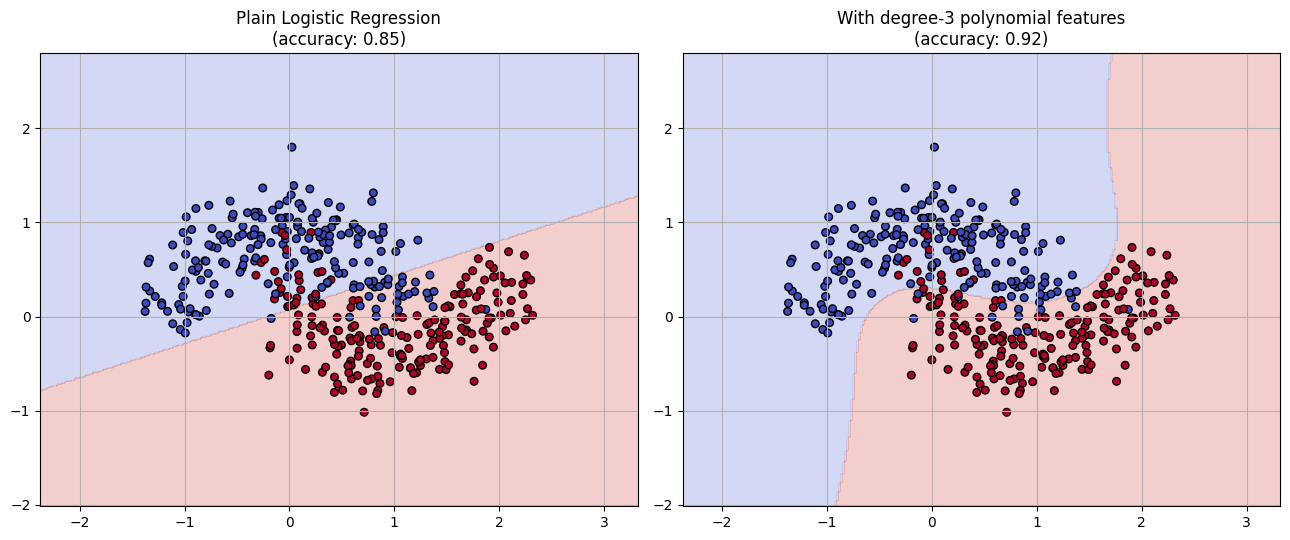

In [17]:
X_moons, y_moons = make_moons(n_samples=400, noise=0.25, random_state=1)

plain_model = LogisticRegression().fit(X_moons, y_moons)

# Engineer curved features, same idea as polynomial regression
poly_model = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LogisticRegression(max_iter=5000)
).fit(X_moons, y_moons)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_decision_boundary(plain_model, X_moons, y_moons, ax=axes[0],
                        title=f"Plain Logistic Regression\n(accuracy: {plain_model.score(X_moons, y_moons):.2f})")
plot_decision_boundary(poly_model, X_moons, y_moons, ax=axes[1],
                        title=f"With degree-3 polynomial features\n(accuracy: {poly_model.score(X_moons, y_moons):.2f})")
plt.tight_layout()
plt.show()


The plain model underfits the curved "moons" shape -- it's still just one straight line.
Adding polynomial features lets the *same underlying linear-in-log-odds model* trace a curved
boundary in the original feature space, exactly as the lecture described: "still linear, now just
linear in a richer, hand-expanded feature space."​

## 14. KNN vs. Decision Tree vs. Logistic Regression, Side by Side

Same curved, interleaving dataset, three completely different strategies for dividing it up.

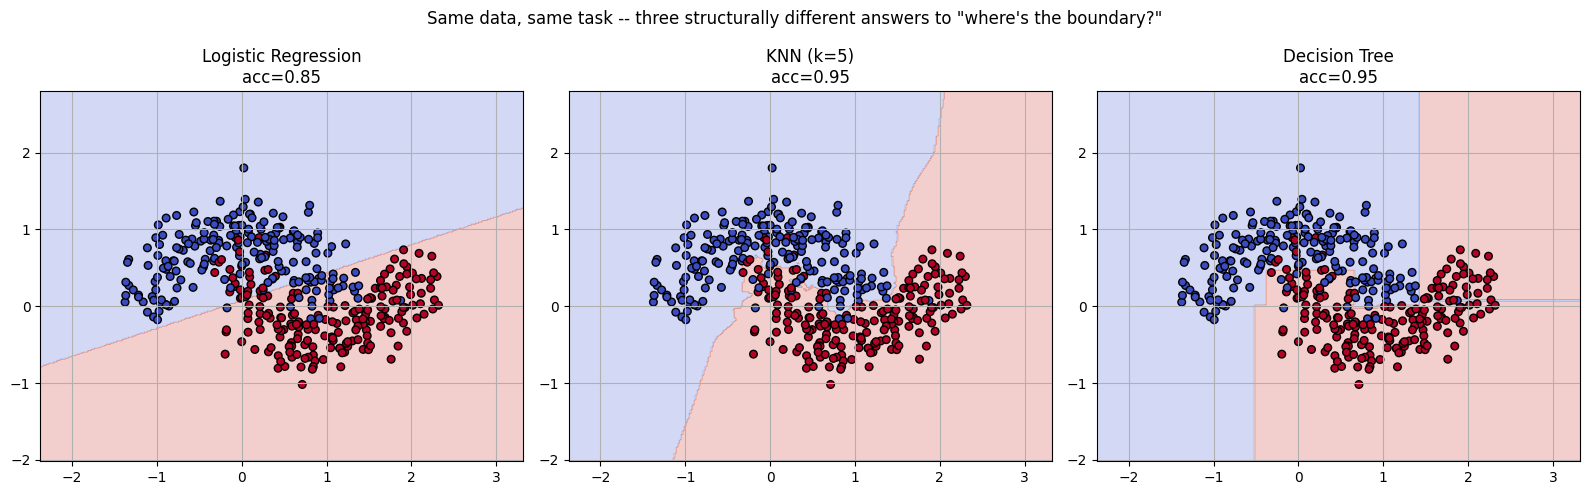

In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=0),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, m) in zip(axes, models.items()):
    m.fit(X_moons, y_moons)
    plot_decision_boundary(m, X_moons, y_moons, ax=ax,
                            title=f"{name}\nacc={m.score(X_moons, y_moons):.2f}")
plt.suptitle('Same data, same task -- three structurally different answers to "where\'s the boundary?"')
plt.tight_layout()
plt.show()


Notice Logistic Regression's panel specifically: forced into a single straight line, it
visibly cannot follow this data's true curved shape. Neither KNN nor the tree is "better" in
general -- each makes a different structural assumption about what boundaries are allowed to
look like.

## 15. Strengths & Weaknesses, in Code

| Strengths | Weaknesses |
|---|---|
| Directly outputs calibrated probabilities, not just a label | Linear decision boundary only |
| Coefficients are genuinely interpretable via odds ratios | Sensitive to feature scaling |
| Fast to train, even on large datasets | Assumes a mostly-linear relationship in log-odds space |
| A strong, well-understood baseline worth trying first | Needs engineered features for curved boundaries |

Let's see the "fast to train" and "calibrated probabilities" strengths directly.

In [19]:
import time

X_big, y_big = make_classification(n_samples=20000, n_features=20, random_state=0)

start = time.time()
LogisticRegression(max_iter=1000).fit(X_big, y_big)
lr_time = time.time() - start

start = time.time()
DecisionTreeClassifier().fit(X_big, y_big)
tree_time = time.time() - start

print(f"Logistic Regression training time: {lr_time:.3f}s")
print(f"Decision Tree training time:       {tree_time:.3f}s")


Logistic Regression training time: 0.014s
Decision Tree training time:       0.706s


In [20]:
# Calibrated probabilities: check that among predictions near p=0.7,
# roughly 70% of the true labels really are 1
model_cal = LogisticRegression().fit(X_churn, y_churn)
p_hat = model_cal.predict_proba(X_churn)[:, 1]

bucket_mask = (p_hat > 0.65) & (p_hat < 0.75)
print(f"Points with predicted P(y=1) in (0.65, 0.75): {bucket_mask.sum()}")
print(f"Actual fraction of those points that are class 1: {y_churn[bucket_mask].mean():.3f}")
print("(Close to the 0.65-0.75 range confirms the probabilities are well calibrated.)")


Points with predicted P(y=1) in (0.65, 0.75): 14
Actual fraction of those points that are class 1: 0.786
(Close to the 0.65-0.75 range confirms the probabilities are well calibrated.)


## 16. The Full Workflow, Once More

Scale features, split data, cross-validate to tune `C`, evaluate with the confusion
matrix / precision / recall / F1 / ROC-AUC toolkit, read coefficients via odds ratios -- every
skill from this course applies directly. Logistic Regression is simply the next option to drop
into the same pipeline.

In [21]:
# 1. Split
X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.25, random_state=42, stratify=y_churn
)

# 2. Scale (fit on train only!)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Cross-validate to tune C
param_grid = {"C": np.logspace(-3, 3, 13)}
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train_scaled, y_train)
best_model = grid.best_estimator_

print("Best C:", grid.best_params_["C"])


Best C: 31.622776601683793


              precision    recall  f1-score   support

    no churn       0.94      0.94      0.94        50
       churn       0.94      0.94      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100

ROC-AUC: 0.9868


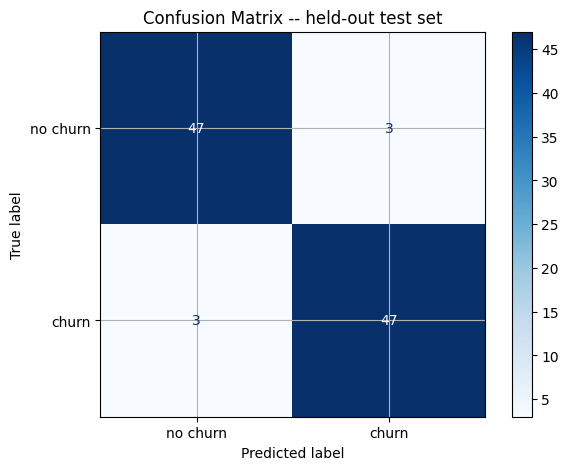

In [22]:
# 4. Evaluate on the held-out test set
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=["no churn", "churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["no churn", "churn"]).plot(cmap="Blues")
plt.title("Confusion Matrix -- held-out test set")
plt.show()


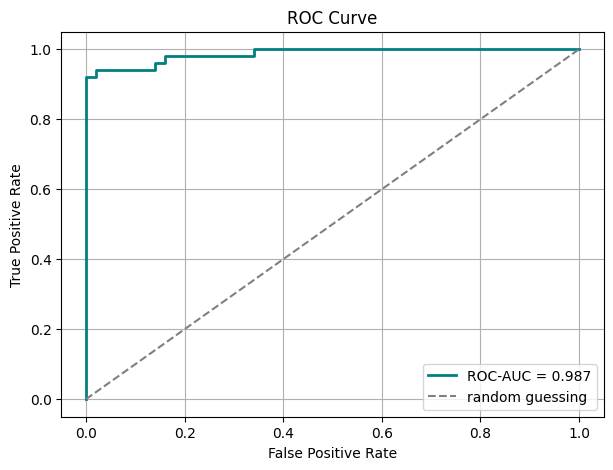

In [23]:
# 5. ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, color="teal", linewidth=2, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [24]:
# 6. Read coefficients via odds ratios, one more time
final_odds_ratios = pd.DataFrame({
    "feature": feature_names,
    "coefficient": best_model.coef_[0].round(3),
    "odds ratio": np.exp(best_model.coef_[0]).round(3)
})
final_odds_ratios


,feature,coefficient,odds ratio
0,monthly_charges,4.499,89.938
1,support_tickets,-3.430,0.032
2,tenure_months,-3.356,0.035


This is exactly what a churn-prediction baseline looks like in practice — every step from
earlier lectures (splitting, scaling, cross-validation, the confusion-matrix toolkit) applies
directly; Logistic Regression just slots into the same pipeline as the model itself.

## 17. Summary

| Idea | Takeaway |
|---|---|
| The equation | `P(y=1) = sigmoid(w·x + b)` -- Linear Regression, squashed into [0, 1] |
| Sigmoid | Any real number in, a valid probability out; z=0 always maps to 0.5 |
| Odds & log-odds | The model is linear in log-odds -- that's the "logistic" in the name |
| Coefficients | `e^w` is the odds ratio -- multiplicative effect on the odds |
| Decision boundary | Always a single straight line or flat plane |
| Training | Maximum likelihood via gradient descent, minimizing log loss |
| Log loss | Punishes confident, wrong predictions far more than cautious ones |
| Regularization | L2 shrinks smoothly; L1 can zero coefficients out; `C` is inverse strength |
| Multiclass | Softmax fits one joint model instead of several one-vs-rest models |
| Limitation | Cannot represent curved boundaries without engineered features |

**Next lecture:** Support Vector Machines -- a different goal entirely (maximizing the *margin*
between the boundary and the nearest points of each class), instead of maximizing likelihood.
